<a href="https://colab.research.google.com/github/CodewithShahriar/Cardiovascular-Heart-Disease-Risk-Forecasting/blob/main/Cardiovascular_Heart_Disease_Risk_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

heart_data = pd.read_csv('heart.csv')

X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print(f'Model Accuracy Score: {test_data_accuracy * 100:.2f}%')

input_data = (57, 1, 0, 140, 192, 0, 1, 148, 0, 0.4, 1, 0, 1)
input_df = pd.DataFrame([input_data], columns=X.columns)
prediction = model.predict(input_df)

if prediction[0] == 0:
    print('The patient is unlikely to have heart disease.')
else:
    print('Warning: The patient shows symptoms of heart disease.')

Model Accuracy Score: 81.46%


In [5]:
import joblib

joblib.dump(model, 'heart_model.pkl')

feature_names = list(X.columns)

with open('app_heart.py', 'w') as f:
    f.write(f"""
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('heart_model.pkl')

st.title("Cardiovascular Heart Disease Prediction System")
st.write("Check the patient's heart status using clinical data.")

age = st.number_input("Age", min_value=1, max_value=120, value=50)
sex = st.selectbox("Sex", options=[1, 0], format_func=lambda x: "Male" if x==1 else "Female")
cp = st.selectbox("Chest Pain Type (0-3)", options=[0, 1, 2, 3])
trestbps = st.number_input("Resting Blood Pressure", min_value=50, max_value=250, value=120)
chol = st.number_input("Serum Cholestoral in mg/dl", min_value=100, max_value=600, value=200)
fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl", options=[1, 0], format_func=lambda x: "True" if x==1 else "False")
restecg = st.selectbox("Resting Electrocardiographic Results (0-2)", options=[0, 1, 2])
thalach = st.number_input("Maximum Heart Rate Achieved", min_value=60, max_value=250, value=150)
exang = st.selectbox("Exercise Induced Angina", options=[1, 0], format_func=lambda x: "Yes" if x==1 else "No")
oldpeak = st.number_input("ST Depression Induced by Exercise", min_value=0.0, max_value=10.0, value=1.0)
slope = st.selectbox("Slope of the Peak Exercise ST Segment (0-2)", options=[0, 1, 2])
ca = st.selectbox("Number of Major Vessels Coloured by Flourosopy (0-4)", options=[0, 1, 2, 3, 4])
thal = st.selectbox("Thalassemia (0-3)", options=[0, 1, 2, 3])

if st.button("Predict Heart Health"):
    input_data = (age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal)
    input_df = pd.DataFrame([input_data], columns={feature_names})
    prediction = model.predict(input_df)

    if prediction[0] == 0:
        st.success('The patient is unlikely to have heart disease.')
    else:
        st.error('Warning: The patient shows symptoms of heart disease!')
""")

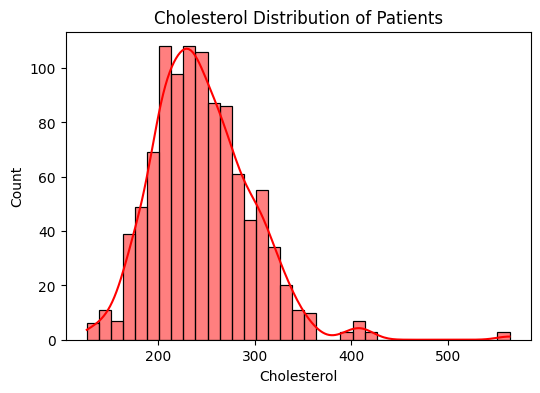

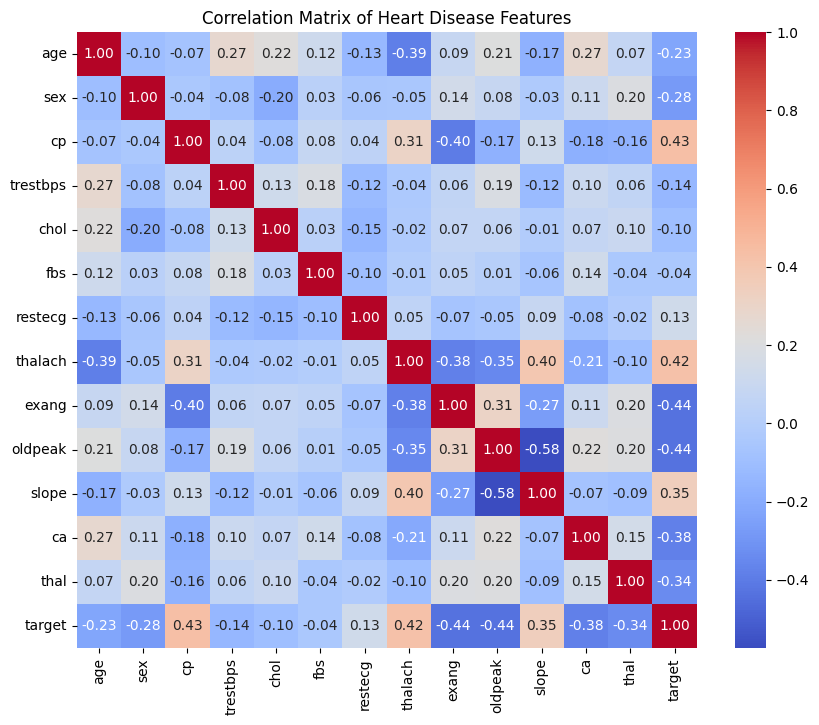

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(heart_data['chol'], kde=True, color='red')
plt.title('Cholesterol Distribution of Patients')
plt.xlabel('Cholesterol')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(heart_data.corr(), annot=True, cmap='heartwarm' if 'heartwarm' in plt.colormaps() else 'coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Heart Disease Features')
plt.show()

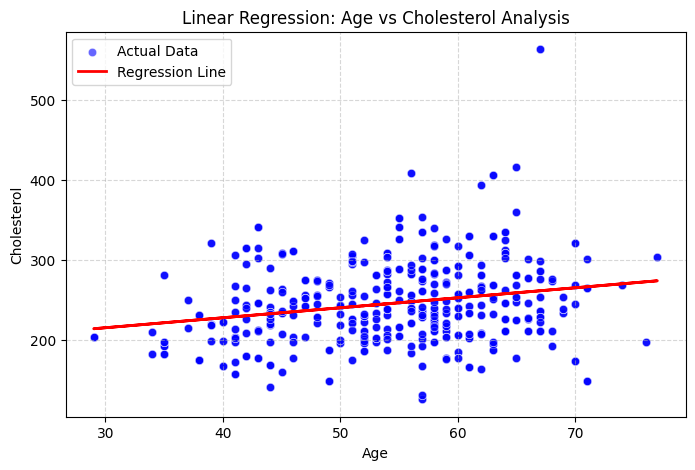

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

X = heart_data[['age']]
y = heart_data['chol']

lr_model = LinearRegression()
lr_model.fit(X, y)
y_pred = lr_model.predict(X)

plt.figure(figsize=(8, 5))

sns.scatterplot(x=heart_data['age'], y=heart_data['chol'], color='blue', alpha=0.6, label='Actual Data')
plt.plot(heart_data['age'], y_pred, color='red', linewidth=2, label='Regression Line')

plt.title('Linear Regression: Age vs Cholesterol Analysis')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [8]:
!pip install streamlit localtunnel -q
!streamlit run app.py & npx localtunnel --port 8501

ERROR: Ignored the following versions that require a different python version: 0.55.2 Requires-Python <3.5
ERROR: Could not find a version that satisfies the requirement localtunnel (from versions: none)
ERROR: No matching distribution found for localtunnel
/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://evil-maps-relax.loca.lt
^C
